# uECG Replay Validation

This notebook compares the raw ECG capture with the firmware replay output to verify that R-peak timing and downstream metrics remain consistent after the recent detector changes.

In [9]:
from pathlib import Path
import subprocess
import sys

RAW_CSV = Path("../data/ecg_5m.csv")
REPLAY_BIN = Path("./replay_ecg")
REPLAY_OUT = Path("./replay_rr_output.csv")

if not RAW_CSV.exists():
    raise FileNotFoundError(f"Missing input capture: {RAW_CSV}")

if not REPLAY_BIN.exists():
    raise FileNotFoundError(
        "Replay binary not found. Build it with:\n"
        "  ./build_tools.sh"
    )

if not REPLAY_OUT.exists():
    print("Running firmware replay to generate RR output…", flush=True)
    completed = subprocess.run(
        [str(REPLAY_BIN), str(RAW_CSV), str(REPLAY_OUT)],
        check=True,
        capture_output=True,
        text=True,
    )
    sys.stdout.write(completed.stdout)
    sys.stderr.write(completed.stderr)

In [10]:
import pandas as pd

ecg_df = pd.read_csv(
    RAW_CSV,
    parse_dates=["time"],
)
ecg_df["elapsed_ms"] = (ecg_df["time"] - ecg_df["time"].iloc[0]).dt.total_seconds() * 1000.0
ecg_df["elapsed_s"] = ecg_df["elapsed_ms"] / 1000.0

rr_df = pd.read_csv(
    REPLAY_OUT,
    comment="#",
)
rr_df["time_s"] = rr_df["time_ms"] / 1000.0
rr_df["bpm_normal"] = rr_df["bpm_normal"].replace(0, pd.NA)
rr_df["bpm_momentary"] = rr_df["bpm_momentary"].replace(0, pd.NA)
rr_df.head()

,rr_id,time_ms,rr_interval_ms,bpm_normal,bpm_momentary,sdrr,rmssd,time_s
0,1,5170.141,5170,11,11,0.0,0.0,5.170141
1,2,5829.504,659,19,91,0.0,0.0,5.829504
2,3,6439.541,610,26,98,0.0,0.0,6.439541
3,4,7080.002,641,32,93,0.0,0.0,7.080002
4,5,7709.571,629,38,95,0.0,0.0,7.709571


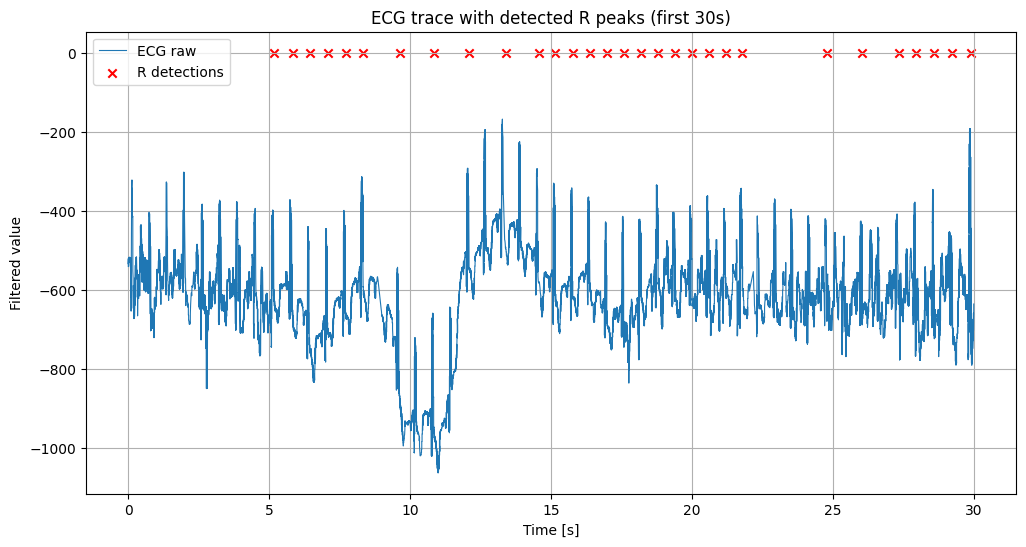

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.grid": True,
})

# Limit the raw plot to the selected window for readability
window_seconds = 30
mask = ecg_df["elapsed_s"] <= window_seconds
plot_df = ecg_df.loc[mask]

fig, ax = plt.subplots()
ax.plot(plot_df["elapsed_s"], plot_df["value"], label="ECG raw", linewidth=0.8)

rr_in_window = rr_df[rr_df["time_s"] <= window_seconds]
ax.scatter(rr_in_window["time_s"], np.zeros_like(rr_in_window["time_s"]),
           marker="x", color="r", label="R detections")

ax.set_title(f"ECG trace with detected R peaks (first {window_seconds}s)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Filtered value")
ax.legend()
plt.show()

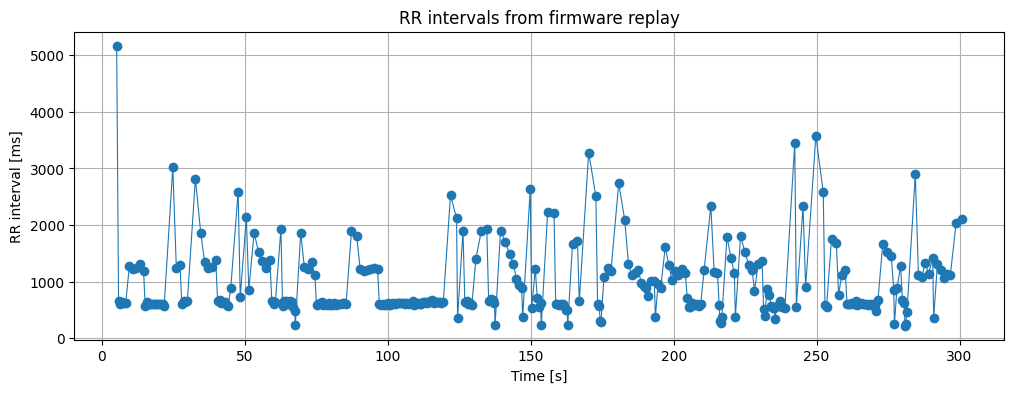

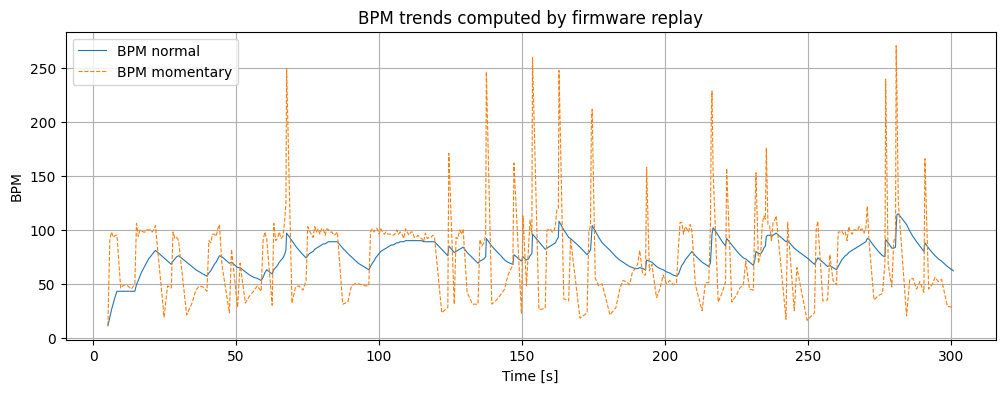

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rr_df["time_s"], rr_df["rr_interval_ms"], marker="o", linestyle="-", linewidth=0.8)
ax.set_title("RR intervals from firmware replay")
ax.set_xlabel("Time [s]")
ax.set_ylabel("RR interval [ms]")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rr_df["time_s"], rr_df["bpm_normal"], label="BPM normal", linewidth=0.8)
ax.plot(rr_df["time_s"], rr_df["bpm_momentary"], label="BPM momentary", linewidth=0.8, linestyle="--")
ax.set_title("BPM trends computed by firmware replay")
ax.set_xlabel("Time [s]")
ax.set_ylabel("BPM")
ax.legend()
plt.show()